# Regression - Combined Cycle Power Plant

**Problem statement:** Predict net hourly electrical energy output (`PE`, MW) from ambient temperature (`AT`), exhaust vacuum (`V`), ambient pressure (`AP`), and relative humidity (`RH`).

**Source:** UCI Machine Learning Repository, dataset 294.

## 1. Setup and reproducibility

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
TARGET = "PE"
FEATURES = ["AT", "V", "AP", "RH"]

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="colorblind")

## 2. Dataset loading and audit

In [2]:
data_path = Path("data/regression.csv")
if not data_path.exists():
    data_path = Path("../data/regression.csv")

df = pd.read_csv(data_path)
assert list(df.columns) == FEATURES + [TARGET], "Unexpected dataset columns"

print(f"Shape: {df.shape}")
display(df.head())

Shape: (9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [3]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100).round(2),
    "unique_values": df.nunique(),
})
display(audit)
print(f"Duplicate rows: {df.duplicated().sum()}")

,dtype,missing_count,missing_percent,unique_values
AT,float64,0,0.0,2773
V,float64,0,0.0,634
AP,float64,0,0.0,2517
RH,float64,0,0.0,4546
PE,float64,0,0.0,4836


Duplicate rows: 41


In [4]:
display(df.describe().T)
display(df[TARGET].describe().to_frame("target_distribution"))

,count,mean,std,min,25%,50%,75%,max
AT,9568.0,19.651231,7.452473,1.81,13.5100,20.345,25.72,37.11
V,9568.0,54.305804,12.707893,25.36,41.7400,52.080,66.54,81.56
AP,9568.0,1013.259078,5.938784,992.89,1009.1000,1012.940,1017.26,1033.30
RH,9568.0,73.308978,14.600269,25.56,63.3275,74.975,84.83,100.16
PE,9568.0,454.365009,17.066995,420.26,439.7500,451.550,468.43,495.76


,target_distribution
count,9568.000000
mean,454.365009
std,17.066995
min,420.260000
25%,439.750000
50%,451.550000
75%,468.430000
max,495.760000


### Audit observation

The dataset contains 9,568 observations, four continuous predictors, and one continuous target. All columns load as `float64` and no values are missing, so imputation is unnecessary. There are 41 exact duplicate rows. `PE` spans 420.26-495.76 MW, with mean 454.37 MW and standard deviation 17.07 MW.

## 3. Exploratory data analysis

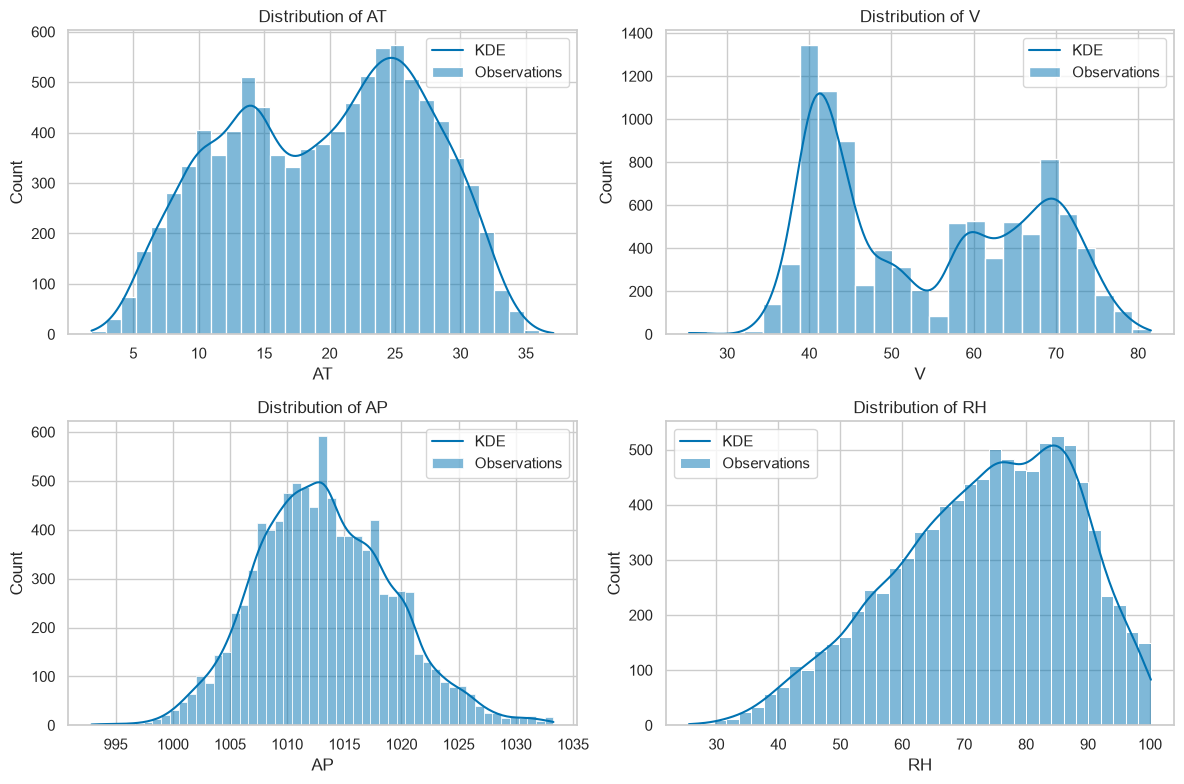

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for feature, axis in zip(FEATURES, axes.flat):
    sns.histplot(df[feature], kde=True, label="Observations", line_kws={"label": "KDE"}, ax=axis)
    axis.set(title=f"Distribution of {feature}", xlabel=feature, ylabel="Count")
    axis.legend()
plt.tight_layout()

### Feature-distribution observation

The predictor distributions show only modest skew: `AT` is nearly symmetric (skew -0.136), while `V` and `AP` are mildly right-skewed (0.199 and 0.265). `RH` has a longer lower-humidity tail (skew -0.432). `AP` is tightly concentrated around 1,013 mbar, whereas temperature and vacuum cover broader operating ranges.

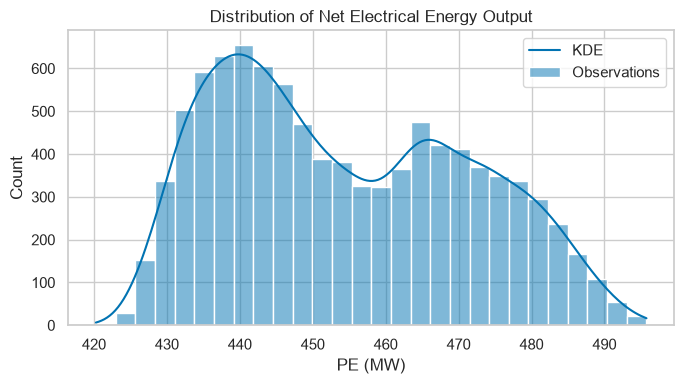

In [6]:
plt.figure(figsize=(7, 4))
sns.histplot(df[TARGET], kde=True, label="Observations", line_kws={"label": "KDE"})
plt.title("Distribution of Net Electrical Energy Output")
plt.xlabel("PE (MW)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()

### Target-distribution observation

Electrical output is centred near 454 MW, with a median of 451.55 MW and mild positive skew (0.307). The target covers a useful 75.5 MW range and has no severe long tail, so R2, RMSE, and MAE can be interpreted directly in the original MW scale without transforming `PE`.

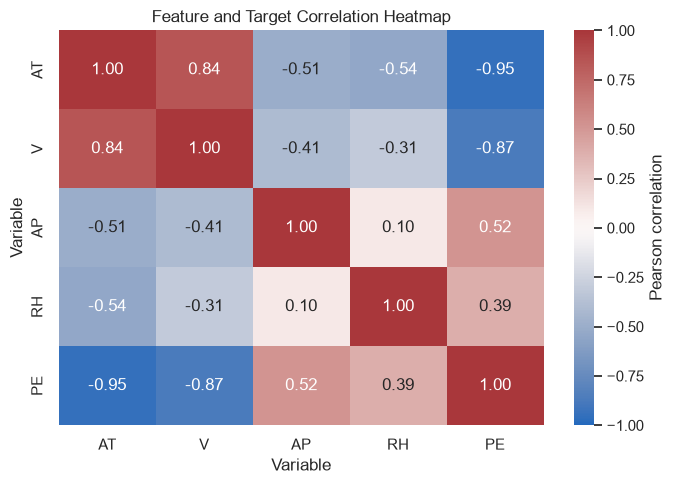

In [7]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, cbar_kws={"label": "Pearson correlation"})
plt.title("Feature and Target Correlation Heatmap")
plt.xlabel("Variable")
plt.ylabel("Variable")
plt.tight_layout()

### Correlation observation

Ambient temperature has the strongest relationship with output (`r = -0.948`), followed by exhaust vacuum (`r = -0.870`). Pressure and humidity have weaker positive correlations with output (`r = 0.518` and `0.390`). `AT` and `V` are also strongly correlated (`r = 0.844`).

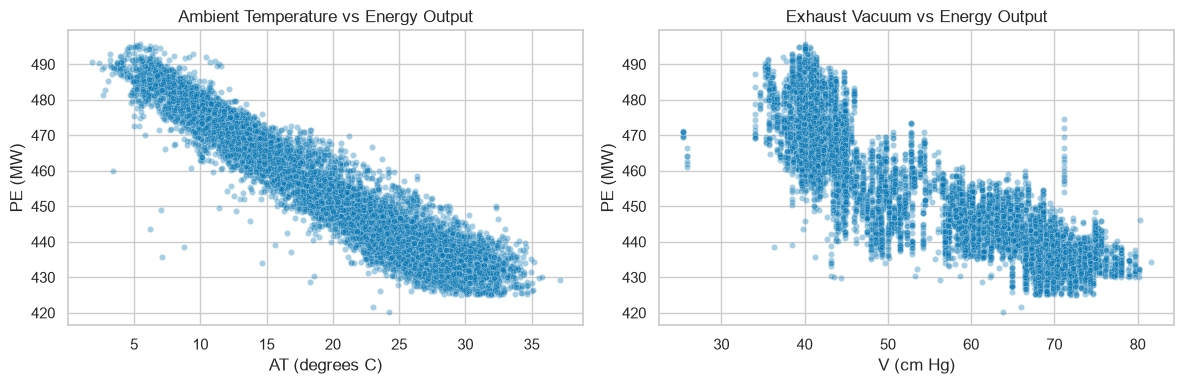

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=df, x="AT", y=TARGET, alpha=0.35, s=20, ax=axes[0])
axes[0].set(title="Ambient Temperature vs Energy Output", xlabel="AT (degrees C)", ylabel="PE (MW)")
sns.scatterplot(data=df, x="V", y=TARGET, alpha=0.35, s=20, ax=axes[1])
axes[1].set(title="Exhaust Vacuum vs Energy Output", xlabel="V (cm Hg)", ylabel="PE (MW)")
plt.tight_layout()

### Feature-target relationship observation

Both scatter plots show that output generally falls as ambient temperature or exhaust vacuum rises. The temperature relationship is especially strong but not perfectly linear, while the vacuum plot shows wider vertical spread at similar values. These patterns justify comparing linear baselines with polynomial, kernel, tree, and ensemble models that can represent interactions and curved responses.

## 4. Cleaning, outliers, feature engineering, and splitting

In [9]:
q1 = df[FEATURES].quantile(0.25)
q3 = df[FEATURES].quantile(0.75)
iqr = q3 - q1
outlier_mask = (df[FEATURES] < (q1 - 1.5 * iqr)) | (df[FEATURES] > (q3 + 1.5 * iqr))
outlier_summary = pd.DataFrame({
    "lower_bound": q1 - 1.5 * iqr,
    "upper_bound": q3 + 1.5 * iqr,
    "iqr_outlier_count": outlier_mask.sum(),
})
display(outlier_summary)

,lower_bound,upper_bound,iqr_outlier_count
AT,-4.80500,44.03500,0
V,4.54000,103.74000,0
AP,996.86000,1029.50000,88
RH,31.07375,117.08375,12


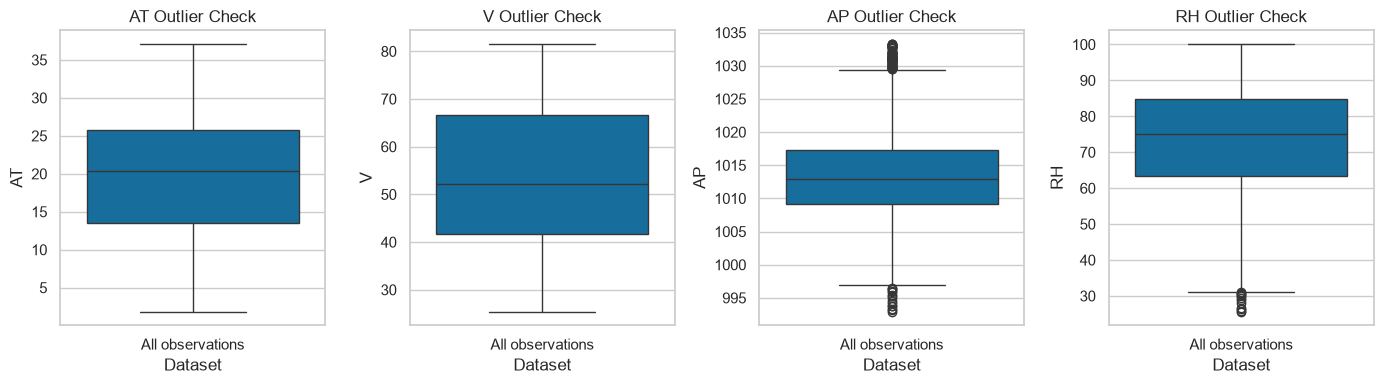

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for feature, axis in zip(FEATURES, axes):
    sns.boxplot(y=df[feature], ax=axis)
    axis.set(title=f"{feature} Outlier Check", xlabel="Dataset", ylabel=feature)
    axis.set_xticks([0], ["All observations"])
plt.tight_layout()

### Cleaning and outlier decision

No values are missing, so imputation is unnecessary. Removing 41 exact duplicates before splitting leaves 9,527 unique rows. The IQR check flags no `AT` or `V` values, 88 `AP` values, and 12 `RH` values. Our outlier-handling decision is to retain these flagged observations, preserving coverage of rare operating conditions. `RobustScaler` uses the training median and interquartile range, making its centring and scaling statistics less sensitive to extreme values.

In [11]:
clean_df = df.drop_duplicates().reset_index(drop=True)
assert clean_df.isna().sum().sum() == 0
print(f"Rows before cleaning: {len(df):,}")
print(f"Rows after duplicate removal: {len(clean_df):,}")

Rows before cleaning: 9,568
Rows after duplicate removal: 9,527


### Engineered feature

The engineered `AT_x_V` interaction represents their combined operating condition. This interaction gives linear and regularised models a direct way to capture that dependence.

In [12]:
clean_df["AT_x_V"] = clean_df["AT"] * clean_df["V"]
MODEL_FEATURES = FEATURES + ["AT_x_V"]

X = clean_df[MODEL_FEATURES]
y = clean_df[TARGET]
display(X.head())

,AT,V,AP,RH,AT_x_V
0,14.96,41.76,1024.07,73.17,624.7296
1,25.18,62.96,1020.04,59.08,1585.3328
2,5.11,39.40,1012.16,92.14,201.3340
3,20.86,57.32,1010.24,76.64,1195.6952
4,10.82,37.50,1009.23,96.62,405.7500


In [13]:
from sklearn.model_selection import train_test_split

target_bins = pd.qcut(y, q=10, duplicates="drop")
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=target_bins,
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "target_mean": [y_train.mean(), y_test.mean()],
    "target_std": [y_train.std(), y_test.std()],
}, index=["train", "test"])
display(split_summary.round(3))

,rows,target_mean,target_std
train,7621,454.332,17.035
test,1906,454.351,17.059


### Preprocessing justification

All five model inputs are numeric and continuous, so categorical encoding is unnecessary. The continuous target is divided into ten quantile bins solely for stratification in the 80:20 train/test split, preserving the full numeric `PE` values for training. The resulting training and test sets contain 7,621 and 1,906 rows.

For scale-sensitive models, scaling is placed inside each pipeline. Tree models use the unscaled predictors. Every model uses the same rows and engineered features.

## 5. Model training and hyperparameter tuning

In [14]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, RobustScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Scaling is kept inside each distance- or coefficient-based model pipeline, so it is fitted separately inside every cross-validation fold. Tree models use the original feature scales.

KNN selects neighbours using Euclidean distance, so a feature with a larger numeric range can dominate which observations count as similar. Without scaling, the engineered `AT_x_V` interaction could outweigh smaller-range predictors simply because of its units. `RobustScaler` centres each feature on its training median and divides by its training interquartile range, making neighbour distances reflect differences across all predictors on comparable scales.

In [15]:
linear_pipeline = Pipeline([
    ("scale", RobustScaler()),
    ("model", LinearRegression()),
])

search_spaces = {
    "Ridge Regression": (
        Pipeline([("scale", RobustScaler()), ("model", Ridge())]),
        {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    ),
    "Lasso Regression": (
        Pipeline([("scale", RobustScaler()), ("model", Lasso(max_iter=30_000))]),
        {"model__alpha": [0.001, 0.01, 0.1, 1.0]},
    ),
    "ElasticNet Regression": (
        Pipeline([("scale", RobustScaler()), ("model", ElasticNet(max_iter=30_000))]),
        {"model__alpha": [0.001, 0.01, 0.1], "model__l1_ratio": [0.2, 0.5, 0.8]},
    ),
    "Polynomial Regression": (
        Pipeline([
            ("polynomial", PolynomialFeatures(include_bias=False)),
            ("scale", RobustScaler()),
            ("model", LinearRegression()),
        ]),
        {"polynomial__degree": [2, 3]},
    ),
    "Decision Tree Regressor": (
        DecisionTreeRegressor(random_state=RANDOM_STATE),
        {"max_depth": [5, 10, 15, None], "min_samples_leaf": [1, 5]},
    ),
    "Random Forest Regressor": (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {"n_estimators": [100, 200], "max_depth": [12, None], "min_samples_leaf": [1, 2]},
    ),
    "Gradient Boosting Regressor": (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {"n_estimators": [100, 200], "learning_rate": [0.03, 0.1], "max_depth": [2, 3]},
    ),
    "Support Vector Regressor": (
        Pipeline([("scale", RobustScaler()), ("model", SVR(cache_size=1000))]),
        {"model__C": [1.0, 10.0], "model__kernel": ["linear", "rbf"], "model__epsilon": [0.1, 0.2]},
    ),
    "K-Nearest Neighbors Regressor": (
        Pipeline([("scale", RobustScaler()), ("model", KNeighborsRegressor(n_jobs=-1))]),
        {"model__n_neighbors": [3, 5, 9, 15], "model__weights": ["uniform", "distance"]},
    ),
}

In [16]:
fitted_models = {}
tuning_rows = []

linear_pipeline.fit(X_train, y_train)
fitted_models["Linear Regression"] = linear_pipeline

for name, (estimator, parameters) in search_spaces.items():
    search = GridSearchCV(
        estimator,
        parameters,
        scoring="r2",
        cv=cv,
        n_jobs=-1,
    )
    search.fit(X_train, y_train)
    fitted_models[name] = search.best_estimator_
    tuning_rows.append({
        "Model": name,
        "Best CV R2": search.best_score_,
        "Best parameters": search.best_params_,
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values("Best CV R2", ascending=False)
with pd.option_context("display.max_colwidth", None):
    display(tuning_results.assign(**{"Best CV R2": tuning_results["Best CV R2"].round(4)}))

,Model,Best CV R2,Best parameters
5,Random Forest Regressor,0.9581,"{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}"
6,Gradient Boosting Regressor,0.9511,"{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}"
8,K-Nearest Neighbors Regressor,0.9500,"{'model__n_neighbors': 9, 'model__weights': 'distance'}"
7,Support Vector Regressor,0.9416,"{'model__C': 10.0, 'model__epsilon': 0.1, 'model__kernel': 'rbf'}"
3,Polynomial Regression,0.9403,{'polynomial__degree': 3}
4,Decision Tree Regressor,0.9396,"{'max_depth': 10, 'min_samples_leaf': 5}"
0,Ridge Regression,0.9338,{'model__alpha': 0.01}
1,Lasso Regression,0.9338,{'model__alpha': 0.001}
2,ElasticNet Regression,0.9337,"{'model__alpha': 0.001, 'model__l1_ratio': 0.8}"


### Hyperparameter-tuning observation

Random Forest achieved the highest mean validation R2 (0.9581), using unrestricted depth and one sample per leaf. This indicates that averaging many high-variance trees controls overfitting better than pruning each tree heavily. Gradient Boosting followed at 0.9511 with 200 estimators, learning rate 0.1, and depth 3, while distance-based KNN reached 0.9500 with nine distance-weighted neighbours. The regularised linear models remained near 0.9338, showing that coefficient shrinkage cannot capture all of the non-linear structure present in the data.

In [17]:
default_models = {
    "Random Forest Regressor": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "Support Vector Regressor": Pipeline([("scale", RobustScaler()), ("model", SVR())]),
}
tuning_gain_rows = []
for name, default_model in default_models.items():
    default_model.fit(X_train, y_train)
    default_r2 = r2_score(y_test, default_model.predict(X_test))
    tuned_r2 = r2_score(y_test, fitted_models[name].predict(X_test))
    tuning_gain_rows.append({
        "Model": name,
        "Default test R2": default_r2,
        "Tuned test R2": tuned_r2,
        "R2 improvement": tuned_r2 - default_r2,
    })
tuning_gain = pd.DataFrame(tuning_gain_rows)
display(tuning_gain.round(4))

,Model,Default test R2,Tuned test R2,R2 improvement
0,Random Forest Regressor,0.9609,0.9611,0.0002
1,Support Vector Regressor,0.9449,0.9475,0.0026


### Tuning-improvement observation

Tuning improved Random Forest test R2 from 0.9609 to 0.9611 and SVR from 0.9449 to 0.9475. The Random Forest gain is small because its defaults already generalise well, whereas tuning SVR's C, epsilon, and kernel produces the larger 0.0026 gain.

In [18]:
prediction_by_model = {}
metric_rows = []

for name, model in fitted_models.items():
    predictions = model.predict(X_test)
    prediction_by_model[name] = predictions
    metric_rows.append({
        "Model": name,
        "R2": r2_score(y_test, predictions),
        "RMSE": root_mean_squared_error(y_test, predictions),
        "MAE": mean_absolute_error(y_test, predictions),
    })

results = pd.DataFrame(metric_rows).sort_values("R2", ascending=False).reset_index(drop=True)
results.index = results.index + 1
display(results.round({"R2": 4, "RMSE": 3, "MAE": 3}))

,Model,R2,RMSE,MAE
1,Random Forest Regressor,0.9611,3.365,2.424
2,K-Nearest Neighbors Regressor,0.9558,3.586,2.626
3,Gradient Boosting Regressor,0.9543,3.646,2.767
4,Support Vector Regressor,0.9475,3.908,2.958
5,Polynomial Regression,0.9446,4.012,3.116
6,Decision Tree Regressor,0.9441,4.033,2.961
7,ElasticNet Regression,0.9363,4.304,3.411
8,Lasso Regression,0.9363,4.306,3.407
9,Ridge Regression,0.9362,4.307,3.407
10,Linear Regression,0.9362,4.307,3.407


### Model-comparison observation

Random Forest is the strongest held-out model: it explains 96.11% of the variation in electrical output, with RMSE 3.365 MW and MAE 2.424 MW. KNN ranks second on all three metrics. The non-linear models generally outperform the linear family, whose R2 values cluster near 0.936; this gap supports the presence of non-linear effects and interactions.

## 6. Cross-validation and model diagnostics

In [19]:
top_two_names = results.head(2)["Model"].tolist()
cv_rows = []
for name in top_two_names:
    scores = cross_val_score(fitted_models[name], X_train, y_train, scoring="r2", cv=cv, n_jobs=-1)
    cv_rows.append({"Model": name, "Mean CV R2": scores.mean(), "CV R2 std": scores.std()})
cv_results = pd.DataFrame(cv_rows).sort_values("Mean CV R2", ascending=False)
display(cv_results.round(4))

,Model,Mean CV R2,CV R2 std
0,Random Forest Regressor,0.9581,0.0063
1,K-Nearest Neighbors Regressor,0.9500,0.0072


### Cross-validation observation

Five-fold cross-validation preserves the ranking: Random Forest averages R2 = 0.9581 (standard deviation = 0.0063), compared with 0.9500 (0.0072) for KNN. Both standard deviations are below 0.01, indicating limited variation.

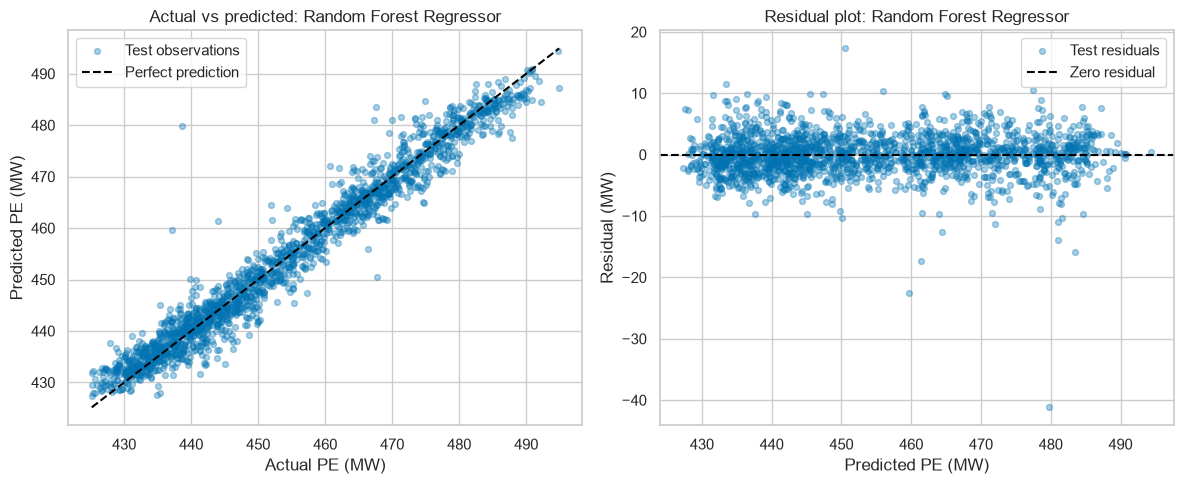

Mean residual: -0.037 MW
Residual standard deviation: 3.366 MW
Residual-prediction correlation: 0.029


In [20]:
best_model_name = results.iloc[0]["Model"]
best_predictions = prediction_by_model[best_model_name]
residuals = y_test - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, best_predictions, alpha=0.35, s=18, label="Test observations")
identity_min = min(y_test.min(), best_predictions.min())
identity_max = max(y_test.max(), best_predictions.max())
axes[0].plot([identity_min, identity_max], [identity_min, identity_max], color="black", linestyle="--", label="Perfect prediction")
axes[0].set(title=f"Actual vs predicted: {best_model_name}", xlabel="Actual PE (MW)", ylabel="Predicted PE (MW)")
axes[0].legend()
axes[1].scatter(best_predictions, residuals, alpha=0.35, s=18, label="Test residuals")
axes[1].axhline(0, color="black", linestyle="--", label="Zero residual")
axes[1].set(title=f"Residual plot: {best_model_name}", xlabel="Predicted PE (MW)", ylabel="Residual (MW)")
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"Mean residual: {residuals.mean():.3f} MW")
print(f"Residual standard deviation: {residuals.std():.3f} MW")
print(f"Residual-prediction correlation: {np.corrcoef(best_predictions, residuals)[0, 1]:.3f}")

### Diagnostic observation

The Random Forest predictions cluster closely around the identity line, consistent with its high R2. The mean residual is -0.037 MW, so aggregate bias is negligible relative to the 3.366 MW residual standard deviation. Residuals remain distributed around zero across most of the prediction range, and their 0.029 correlation with predictions indicates almost no remaining linear direction. A few larger errors remain, which explains why RMSE exceeds MAE, but no dominant funnel shape is visible.

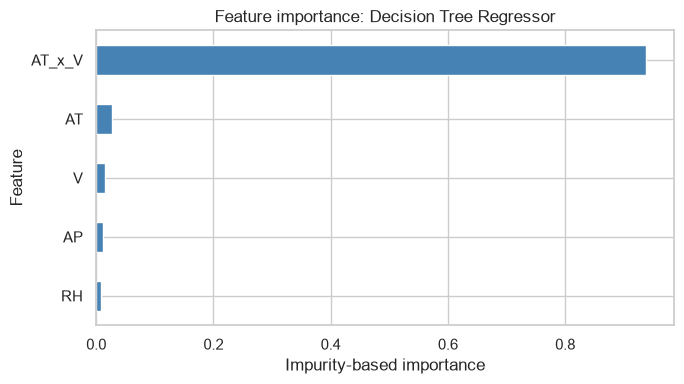

,Importance
AT_x_V,0.9387
AT,0.0266
V,0.0155
AP,0.0117
RH,0.0075


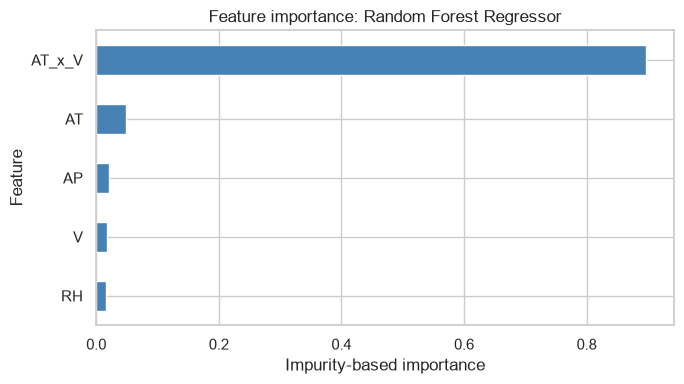

,Importance
AT_x_V,0.8976
AT,0.0493
AP,0.0204
V,0.0171
RH,0.0156


In [21]:
for tree_model_name in ["Decision Tree Regressor", "Random Forest Regressor"]:
    tree_model = fitted_models[tree_model_name]
    feature_importance = pd.Series(tree_model.feature_importances_, index=X_train.columns).sort_values()
    fig, ax = plt.subplots(figsize=(7, 4))
    feature_importance.plot.barh(ax=ax, color="steelblue")
    plt.title(f"Feature importance: {tree_model_name}")
    plt.xlabel("Impurity-based importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
    display(feature_importance.sort_values(ascending=False).rename("Importance").round(4).to_frame())

### Feature-importance observation

The engineered `AT_x_V` interaction dominates Random Forest importance at 0.8976, followed by `AT` at 0.0493; `AP`, `V`, and `RH` each contribute about 0.02 or less. Decision Tree also ranks `AT_x_V` first (0.9387) and `AT` second (0.0266), assigning a larger share of its impurity reduction to the interaction than Random Forest does. This supports the feature-engineering hypothesis that the joint temperature-exhaust-vacuum condition contains useful non-linear signal.

In [22]:
linear_coefficients = pd.Series(
    fitted_models["Linear Regression"].named_steps["model"].coef_,
    index=X_train.columns,
    name="Scaled coefficient",
).sort_values(key=abs, ascending=False)
lasso_coefficients = fitted_models["Lasso Regression"].named_steps["model"].coef_
display(linear_coefficients.round(4).to_frame())
print(f"Lasso zero coefficients: {(lasso_coefficients == 0).sum()} of {len(lasso_coefficients)}")

,Scaled coefficient
AT,-35.3681
AT_x_V,22.0833
V,-17.3634
RH,-2.7974
AP,0.7173


Lasso zero coefficients: 0 of 5


### Linear-model observation

On the robust-scaled inputs, Linear Regression assigns its largest absolute coefficient to `AT` (-35.3681), followed by `AT_x_V` (+22.0833) and `V` (-17.3634). Higher temperature and exhaust vacuum are therefore associated with lower predicted output. Lasso retains all five coefficients at its selected alpha, so regularisation shrinks the model without feature elimination.